In [1]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from joblib import load
from tqdm import tqdm
import warnings

from sklearn.metrics import classification_report
warnings.filterwarnings("ignore")
import glob
import os
from collections import OrderedDict 
 
import numpy as np
import matplotlib.pyplot as plt  

import pandas as pd 


In [2]:


class Helix:
    def __init__(self,r,z,theta_0,
                 pitch,xyz_origin = (0,0,0),n_points = 300, z_orientation = 'z'):
        self.r = r

        self.pitch = pitch
        self.origin_x,self.origin_y,self.origin_z = xyz_origin
        self.theta_0 = theta_0
        self.n_points = n_points
        self.z_orientation = z_orientation
        self.t = np.linspace(0,z,n_points)
        self.theta = 2*np.pi*self.t/self.pitch
        self.helix_points = self.to_xyz()

    def rotate(self,direction = 'z->x'):
        s = direction.split('->')
        key_value = {'x':'x','y':'y','z':'z'} 
        #print({key_value[key]:value for key,value in s})
        
    def to_xyz(self,points = None):
        
        if points is not None:
            assert any([isinstance(points,list),isinstance(points,tuple)])
            points = np.array(points)
            theta = 2* np.pi * points/ self.pitch
            x = self.r * np.cos(theta[:,0]+ self.theta_0 ) 
            y = self.r * np.sin(theta[:,1] + self.theta_0) 
            z = points[:,2]
            pts = pts = np.column_stack((x, y, z))
            return pts
        x = self.r * np.cos(2*np.pi*self.t/self.pitch + self.theta_0) + self.origin_x
        y = self.r * np.sin(2*np.pi*self.t/self.pitch + self.theta_0) + self.origin_y
        z = self.t
        pts = np.column_stack((x, y, z))
        return pts
    
    
    def plot_helix(self,figsize = (10,10)):
        plt.rcParams.update({
        'xtick.color':'w', 'ytick.color':'w',
        'axes.edgecolor':'w', 'axes.labelcolor':'w',
        'font.size':12, 'xtick.major.pad':12, 'ytick.major.pad':12,
        })
        fig = plt.figure(figsize =(15,15),facecolor='black',)
        subplot = fig.add_subplot(projection='3d', facecolor='grey',
                                    xlabel='X', ylabel='Y', zlabel='Z',
                                    title= '')
        # for (x, y, z) in points:
        #    plt.plot(x, y, z, marker='o', color='red')
        
        subplot.plot(self.helix_points.T[0],
                     self.helix_points.T[1],
                     self.helix_points.T[2],
                        color='red', linestyle='dashdot',
                            )

    
    def plot_points_on_helix(self,points):
        assert any([isinstance(points,list),isinstance(points,tuple)])
        plt.rcParams.update({
        'xtick.color':'w', 'ytick.color':'w',
        'axes.edgecolor':'w', 'axes.labelcolor':'w',
        'font.size':12, 'xtick.major.pad':12, 'ytick.major.pad':12,
        })
        fig = plt.figure(figsize =(15,15),facecolor='black',)
        self.plot_helix()
        points = self.to_xyz(points)
        #points[:,2] = points[:,2]/points[:,2].max() 
        for (x, y, z) in points:
            #print(x,y,z)
            plt.plot(x, y,self.r  * z, marker='.', color='red')

In [3]:
#Helix(20,10,1,5).plot_helix()

points =np.random.normal(4*np.pi,(1/2)*np.pi,100) 
points = np.concatenate([[points],[points],[points]],axis =0).T
 

In [6]:
import yaml
import numpy as np
from src.data.modules.LitData  import LitData
from src.layers.selfsupervised.lightcurve import LightCurveClassifier

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import numpy as np
DICT = {
    "AGN": 0,
    "QSO": 1,
    "EA": 2,
    "YSO": 3,
    "SNIa": 4,
    "CV/Nova": 5,
    "RRLc": 6,
    "RSCVn": 7,
    "Blazar": 8,
    "SNII": 9,
    "EB/EW": 10,
    "LPV": 11,
    "CEP": 12,
    "RRLab": 13,
    "Periodic-Other": 14,
    "DSCT": 15,
    "SNIbc": 16,
    "SLSN": 17,
    "TDE": 18,
    "SNIIb": 19,
    "SNIIn": 20,
    "Microlensing": 21
    }
def produce_report(path_1):
    path_args = glob.glob(f"{path_1}*args*")[0]
    #print(path_args)
   
    with open(path_args, 'r') as file:
        args = yaml.safe_load(file)
    #print('Initializing models') 
    model = LightCurveClassifier(**args) 
    #print('Loading checkpoints')
    checkpoint_path_clip = glob.glob(
        f"{path_1}*my_best_checkpoint*"
    ) 
    #print(checkpoint_path_clip[-1])
    checkpoint_clip = torch.load(checkpoint_path_clip[-1], map_location=torch.device('cuda:2'))
    od_atat = OrderedDict() 
    for key in checkpoint_clip["state_dict"].keys(): 
            #print(key)
            if 'project' in key:
                continue
            if 'model' in key:
                od_atat[key.replace("model.", "")] = checkpoint_clip["state_dict"][key]

    model.load_state_dict(od_atat,strict=True)
    args['general']['data_root'] = 'data/datasets/ZTF_ff/final/LC_MD_FEAT_240627_windows_200_12'
    args['general']['use_sampler'] = False
    args['general']['batch_size'] = 256

    pl_datal = LitData(**args['general'])
    dataloader = pl_datal.test_dataloader() 
    target = None
    preds_out = None

    model.eval().to(device = 'cuda:2')  

    for b1 in tqdm(dataloader):

        #print(b1.keys())
        b1 = {key:value.to(device = 'cuda:2') for key, value in b1.items()}
        #print(b1['mask'].sum(dim = [1,2])[0])
        lc_emb = model(**b1)  
        t = b1['labels']
        preds_out = (
            np.concatenate([preds_out, torch.argmax(lc_emb, axis=1).detach().cpu().numpy()])
            if preds_out is not None
            else torch.argmax(lc_emb, axis=1).cpu().detach().numpy()
        )
        target = (
            np.concatenate([target, t.cpu().detach().numpy()])
            if target is not None
            else t.detach().cpu().numpy()
        )
    results = preds_out
    classification = classification_report(target, results, target_names=list(DICT.keys()),digits = 4)
    print(classification)
    data_dict =  classification_report(target, results, target_names=list(DICT.keys()),digits = 4, output_dict=True)    
    from src.utils.plottinglib import elasticc_confusion_matrix
    out_metrics_balto = classification_report(
        target, results, target_names=list(DICT.keys()), output_dict=True
    )["macro avg"]
    template_balto = ""
    for key in out_metrics_balto.keys():
        template_balto += " {} : {:.3f} ".format(key.upper(), out_metrics_balto[key])
    fig, axes = plt.subplots(1, 1, figsize=(12, 12))
    elasticc_confusion_matrix(
        y_true=np.array(target).astype(int),
        y_pred=np.array(results).astype(int),
        classes= np.array(list(DICT.keys())),
        ax=axes,
        normalize=True,
        title=f" FClassifier Results [TEST] \n\n {template_balto}",
    )
    plt.show()
     
    return data_dict

In [4]:
path_1  = '/home/mdelafuente/pipeline/pipeline/training/lc_classifier_ztf/ATAT_ALeRCE/results/ZTF_ff/LC/SPRING_TEST_v01_0/'
path_2 = '/home/mdelafuente/pipeline/pipeline/training/lc_classifier_ztf/ATAT_ALeRCE/results/ZTF_ff/LC/TEST_residual_0/'

using set test total of idx : 50501 
                 use_lightcurves True, use_metadata False 
                 use_features False 
                      use MTA False
using set_Type test
NOT USING SAMPLER FOR DATASET test
<generator object Module.named_parameters at 0x7f5658927b40>
min,max -0.3998214 0.40213406


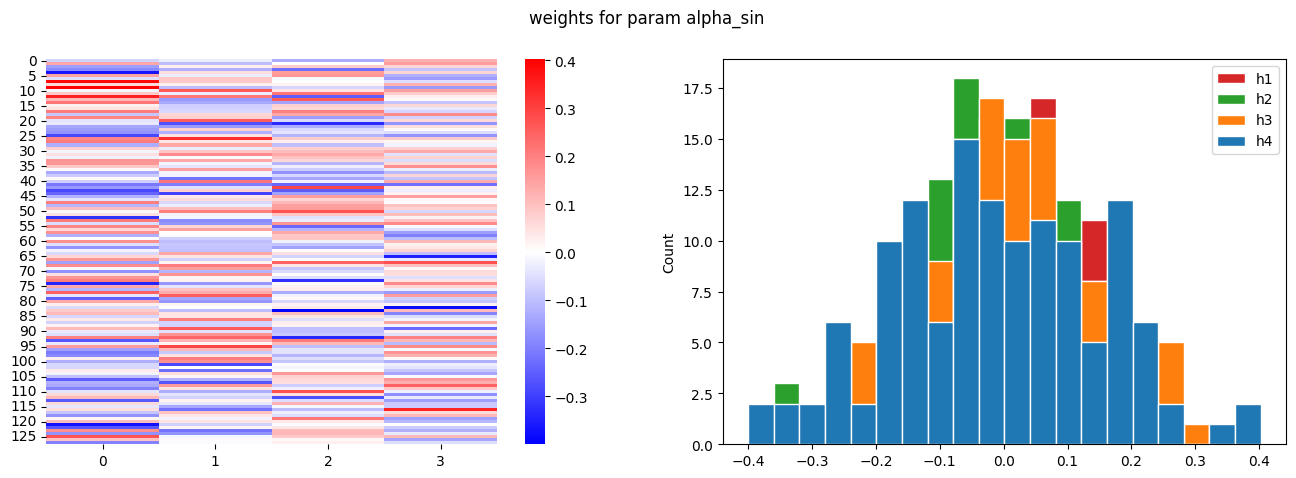

min,max -0.32940668 0.37471846


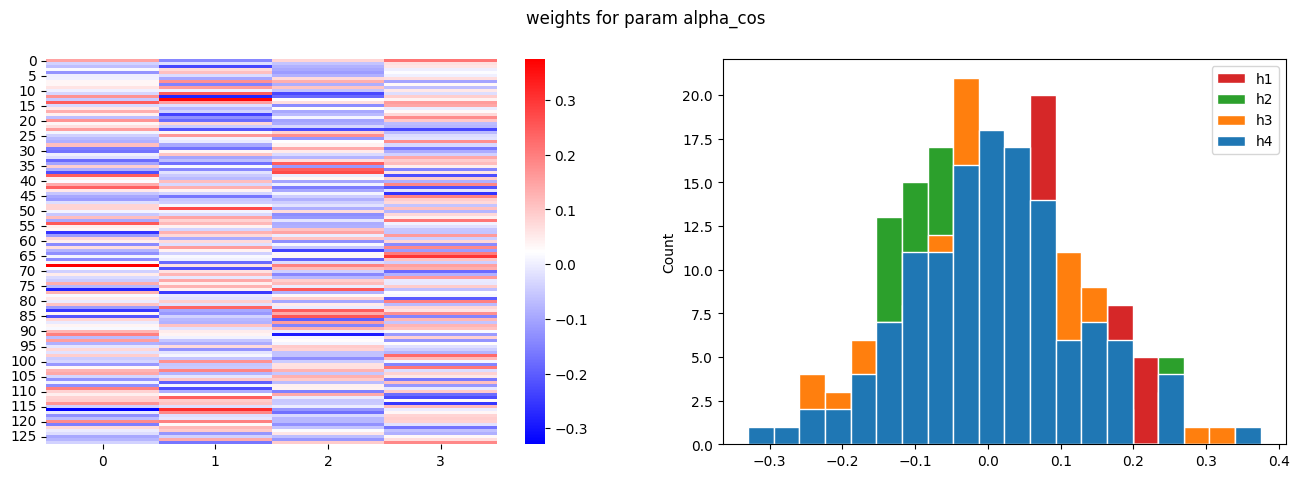

min,max -0.46191216 0.46191216


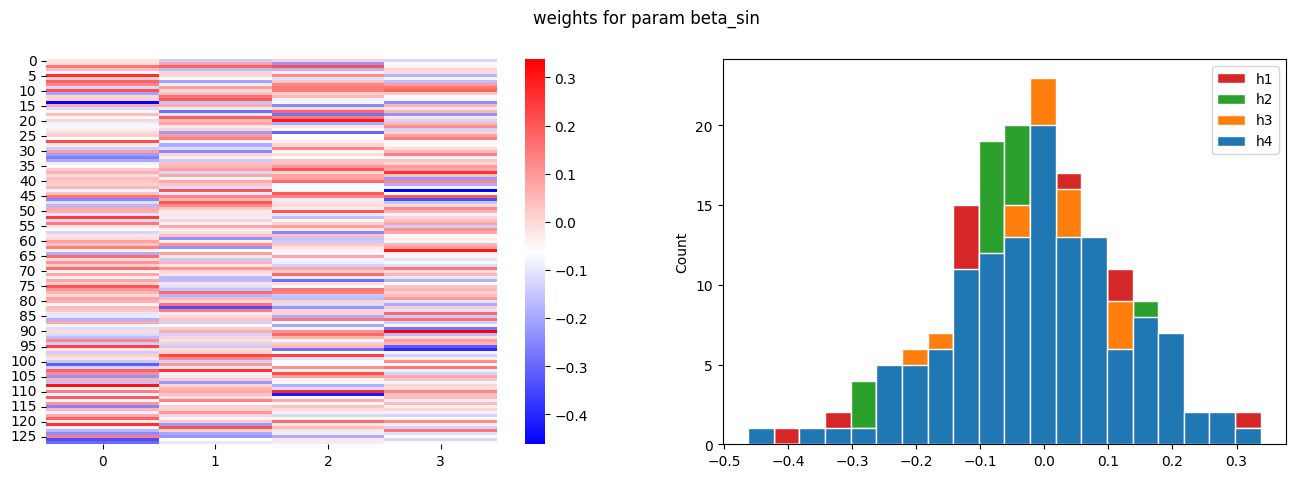

min,max -0.39466342 0.39466342


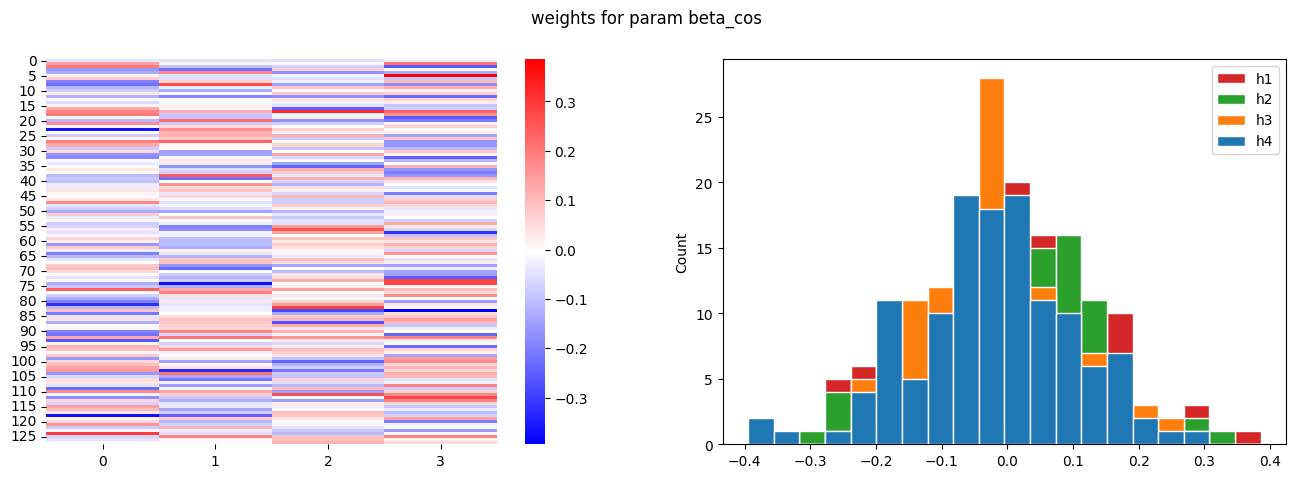

In [8]:
def get_fourier_coeffs(path_1):
    path_args = glob.glob(f"{path_1}*args*")[0]
    #print(path_args)
   
    with open(path_args, 'r') as file:
        args = yaml.safe_load(file)
    #print('Initializing models') 
    model = LightCurveClassifier(**args) 
    #print('Loading checkpoints')
    checkpoint_path_clip = glob.glob(
        f"{path_1}*my_best_checkpoint*"
    ) 
    #print(checkpoint_path_clip[-1])
    checkpoint_clip = torch.load(checkpoint_path_clip[-1], map_location=torch.device('cuda:2'))
    od_atat = OrderedDict() 
    for key in checkpoint_clip["state_dict"].keys(): 
            #print(key)
            if 'project' in key:
                continue
            if 'model' in key:
                od_atat[key.replace("model.", "")] = checkpoint_clip["state_dict"][key]

    model.load_state_dict(od_atat,strict=True)
    args['general']['data_root'] = 'data/datasets/ZTF_ff/final/LC_MD_FEAT_240627_windows_200_12'
    args['general']['use_sampler'] = False
    args['general']['batch_size'] = 256

    pl_datal = LitData(**args['general'])
    dataloader = pl_datal.test_dataloader() 
    target = None
    preds_out = None

    model.eval().to(device = 'cuda:2')
    time_encoder=alpha_sin = model.LC.time_encoder.time_encoders[0]
    print(time_encoder.named_parameters())
    for name,param in time_encoder.named_parameters():
        if name in ['alpha_sin','alpha_cos','beta_sin', 'beta_cos']:
            fig = plt.figure(figsize=(16,5))
            weights = param.detach().cpu().numpy()
            #weights = weights/ abs(weights).max()
            print("min,max",weights.min(),abs(weights).max())
            ax1 =  fig.add_subplot(121)
            ax2 =  fig.add_subplot(122)
            sns.heatmap(weights.T,ax = ax1, cmap = 'bwr')
            sns.histplot(weights.T,ax =  ax2,bins = 20,color = 'bwr', edgecolor = 'w',alpha = 1)
            plt.legend(['h1','h2','h3','h4'])
            plt.suptitle(f"weights for param {name}")
            plt.show()
        else:
            continue
    
import seaborn as sns
get_fourier_coeffs(path_1)

using set test total of idx : 50501 
                 use_lightcurves True, use_metadata False 
                 use_features False 
                      use MTA False
using set_Type test
NOT USING SAMPLER FOR DATASET test


  0%|          | 0/197 [00:00<?, ?it/s]


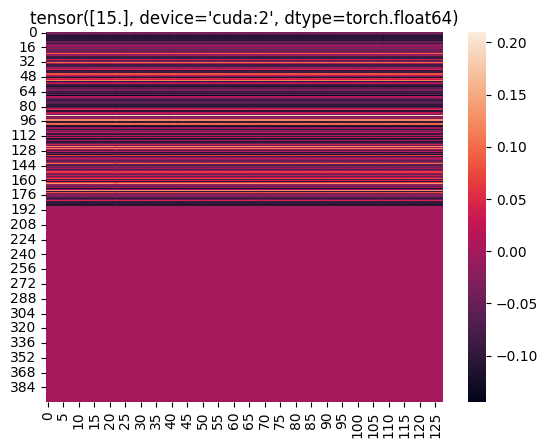

In [58]:
def see_alpha_beta(path_1):
    path_args = glob.glob(f"{path_1}*args*")[0]
    #print(path_args)
   
    with open(path_args, 'r') as file:
        args = yaml.safe_load(file)
    #print('Initializing models') 
    model = LightCurveClassifier(**args) 
    #print('Loading checkpoints')
    checkpoint_path_clip = glob.glob(
        f"{path_1}*my_best_checkpoint*"
    ) 
    #print(checkpoint_path_clip[-1])
    checkpoint_clip = torch.load(checkpoint_path_clip[-1], map_location=torch.device('cuda:2'))
    od_atat = OrderedDict() 
    for key in checkpoint_clip["state_dict"].keys(): 
            #print(key)
            if 'project' in key:
                continue
            if 'model' in key:
                od_atat[key.replace("model.", "")] = checkpoint_clip["state_dict"][key]

    model.load_state_dict(od_atat,strict=True)
    args['general']['data_root'] = 'data/datasets/ZTF_ff/final/LC_MD_FEAT_240627_windows_200_12'
    args['general']['use_sampler'] = False
    args['general']['batch_size'] = 256

    pl_datal = LitData(**args['general'])
    dataloader = pl_datal.test_dataloader() 
    target = None
    preds_out = None

    model.eval().to(device = 'cuda:2')  

    for b1 in tqdm(dataloader):

        #print(b1.keys())
        b1 = {key:value.to(device = 'cuda:2') for key, value in b1.items()}
        #print(b1['mask'].sum(dim = [1,2])[0])
        x_mod,t_mod,m_mod = model.LC.time_encoder(**{'x': b1['data'],'t':b1['time'],'mask': b1['mask']})  
        t = b1['labels']
        x_mod = x_mod/ torch.norm(x_mod, dim = 1,keepdim = True)
        x_mod = x_mod.detach().cpu().numpy()
        t_mod = t_mod.detach().cpu().numpy()
        m_mod = m_mod.detach().cpu().numpy()
        break
    n = torch.randint(0,128,size = (1,))
    sns.heatmap(x_mod[n,:,:])
    plt.title( f'{(t[n])}')
     
     
see_alpha_beta(path_1)

In [6]:
import torch
import torch.nn as nn
from src.layers.tokenEmbeddings.Token import Token

from src.layers.ATAT import TimeHandler
class LightCurveEncoder(nn.Module):
    def __init__(self, **kwargs):
        super(LightCurveEncoder, self).__init__() 
        self.time_encoder = TimeHandler(**kwargs['lc'])
        #self.token_lc = Token(**kwargs['lc'])
        self.bottleneck= nn.Sequential(nn.Linear(kwargs['lc']['embedding_size'],32))
        n = 3
        self.decoder = nn.Sequential(nn.Linear(32,kwargs['lc']['embedding_size']*n),
                                     nn.GELU(),
                                     nn.LayerNorm(kwargs['lc']['embedding_size']*n),
                                     nn.Linear(kwargs['lc']['embedding_size']*n,kwargs['lc']['embedding_size']*n),
                                     nn.GELU(),
                                     nn.LayerNorm(kwargs['lc']['embedding_size']*n),
                                     nn.Linear(kwargs['lc']['embedding_size']*n,kwargs['lc']['embedding_size']*n),
                                     nn.GELU(),
                                     nn.LayerNorm(kwargs['lc']['embedding_size']*n),
                                     nn.Linear(kwargs['lc']['embedding_size']*n,1))
        
    def embedding_light_curve(self, x, t, mask=None, **kwargs):
        x_mod, m_mod, t_mod = self.time_encoder(**{"x": x, "t": t, "mask": mask})
       # x_mod = torch.cat([self.token_lc(x.shape[0]), x_mod], axis=1)
       # m_mod =  torch.cat([torch.ones(1, 1, 1,device=x.device).bool().repeat(x.shape[0],1,1), m_mod], axis=1)
        return x_mod, m_mod , t_mod

    def forward(self, data, time, mask, **kwargs):
        x_mod, m_mod, _ = self.embedding_light_curve(**{"x": data, "t": time, "mask": mask}) 
        m_mod =  ~(m_mod.squeeze(-1))
        compressed = self.bottleneck(x_mod)
        decoded = self.decoder(compressed)
        return data,decoded.reshape(data.shape)
    
path_args = glob.glob(f"{path_1}*args*")[0]
with open(path_args, 'r') as file:
    args = yaml.safe_load(file)
#print('Initializing models') 
model = LightCurveEncoder(**args) 
#print('Loading checkpoints')
checkpoint_path_clip = glob.glob(
    f"{path_1}*my_best_checkpoint*"
) 
#print(checkpoint_path_clip[-1])
checkpoint_clip = torch.load(checkpoint_path_clip[-1], map_location=torch.device('cuda:2'))
od_atat = OrderedDict() 
for key in checkpoint_clip["state_dict"].keys(): 
        #print(key)
        if 'time_encoder' not in key :
            continue
        else:
            od_atat[key.replace("model.LC.time_encoder.", "")] = checkpoint_clip["state_dict"][key]

model.time_encoder.load_state_dict(od_atat,strict=True)

for param in model.time_encoder.parameters():
    param.requires_grad = False
 
args['general']['data_root'] = 'data/datasets/ZTF_ff/final/LC_MD_FEAT_240627_windows_200_12'
args['general']['use_sampler'] = False
args['general']['batch_size'] = 512

pl_datal = LitData(**args['general'])
train_dataloader = pl_datal.train_dataloader() 
val_dataloader = pl_datal.val_dataloader() 


using set train total of idx : 161611 
                 use_lightcurves True, use_metadata False 
                 use_features False 
                      use MTA False
using set_Type train
NOT USING SAMPLER FOR DATASET train
using set validation total of idx : 40698 
                 use_lightcurves True, use_metadata False 
                 use_features False 
                      use MTA False
using set_Type validation
NOT USING SAMPLER FOR DATASET validation


In [7]:
input_dict = {'data': torch.rand((10,200,2)), 'time': torch.rand((10,200,2)), 'mask': torch.rand((10,200,2))> 0.5}
data,decoded = model(**input_dict)
decoded.shape


torch.Size([10, 200, 2])

In [22]:
import torch
import torch.nn as nn
from torch.optim import AdamW
from tqdm import tqdm
from src.losses.VICReg import VICReg
your_model = model
# Define loss function

# Training loop
num_epochs = 100  # Change as needed
device = torch.device("cuda:2" if torch.cuda.is_available() else "cpu")
optimizer = AdamW(your_model.parameters(), lr= 1e-3)
your_model.to(device)
criterion = nn.MSELoss()
for epoch in range(num_epochs):
    # Training phase
    batch_count = 0
    your_model.train()
    train_loss = 0.0
    for batch in train_dataloader:
        optimizer.zero_grad()
        
        batch_data = batch
        batch_data  = {key:value.to(device) for key,value in batch_data.items()}
       # aug_batch_data  = {key:value.to(device) for key,value in aug_batch_data.items()}
        data,decoded = your_model(**batch_data)
        #aug_x_emb = your_model(**aug_batch_data)
         
        loss = torch.sqrt(criterion(decoded,data))
        
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        if batch_count %10 == 0:
            print(f'-- Batch count: {batch_count}/ {len(train_dataloader)} || Step Loss: {loss:.2f}', end = '\r') # || cov {loss_dict["not_weighted_cov"]:.4f} || var {loss_dict["not_weighted_1menos_var"]:.4f} || inv {loss_dict["not_weighted_inv"]:.4f}', end = '\r')
        batch_count +=1
    train_loss /= len(train_dataloader)  # Average loss over batches
    
    # Validation phase
    your_model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch in val_dataloader:
            batch_data = batch
            batch_data  = {key:value.to(device) for key,value in batch_data.items()}
            #aug_batch_data  = {key:value.to(device) for key,value in aug_batch_data.items()}
            data,decoded = your_model(**batch_data)
            loss = torch.sqrt(criterion(decoded,data))

            
            val_loss += loss.item()
    
    val_loss /= len(val_dataloader)  # Average loss over batches
    
    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")


KeyboardInterrupt: 

using set test total of idx : 50501 
                 use_lightcurves True, use_metadata False 
                 use_features False 
                      use MTA False
using set_Type test
NOT USING SAMPLER FOR DATASET test


100%|██████████| 197/197 [01:26<00:00,  2.28it/s]


                precision    recall  f1-score   support

           AGN     0.3543    0.1848    0.2429      3933
           QSO     0.5612    0.4162    0.4779      4099
            EA     0.6361    0.5386    0.5833      4352
           YSO     0.2769    0.2258    0.2487      3295
          SNIa     0.2778    0.0046    0.0091      2162
       CV/Nova     0.3561    0.2623    0.3021      1944
          RRLc     0.6181    0.3005    0.4044      4233
         RSCVn     0.2896    0.2244    0.2529      3119
        Blazar     0.1414    0.1615    0.1508      1703
          SNII     0.1741    0.2912    0.2179      1037
         EB/EW     0.4557    0.6008    0.5183      4607
           LPV     0.4894    0.5255    0.5068      4135
           CEP     0.2506    0.2150    0.2314      3507
         RRLab     0.5466    0.2761    0.3668      4423
Periodic-Other     0.0741    0.3372    0.1214       872
          DSCT     0.2485    0.5037    0.3328      2051
         SNIbc     0.0225    0.0503    0.0311  

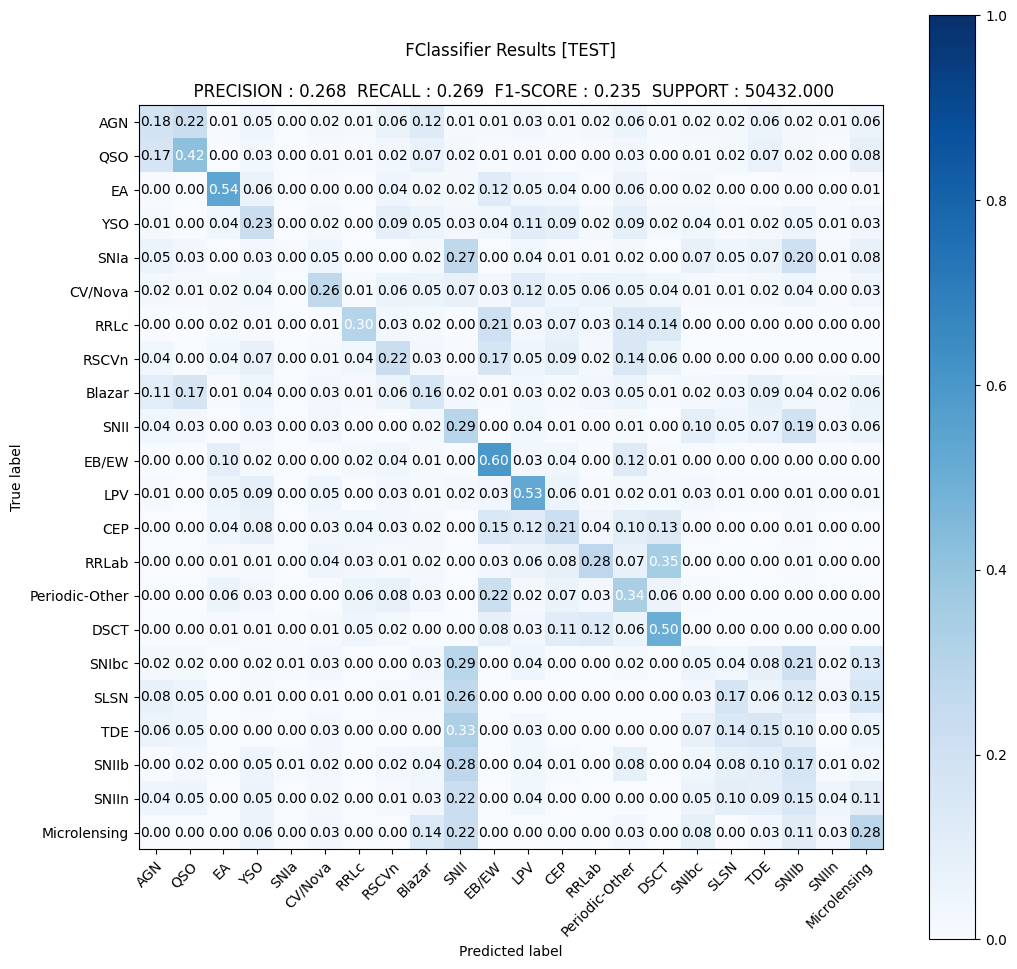

In [9]:
data_dict_1 = produce_report(path_1)

In [15]:
data_dict_2 = produce_report(path_2)

using set test total of idx : 50501 
                 use_lightcurves True, use_metadata False 
                 use_features False 
                      use MTA False
using set_Type test
NOT USING SAMPLER FOR DATASET test


 27%|██▋       | 54/197 [00:04<00:12, 11.05it/s]


KeyboardInterrupt: 

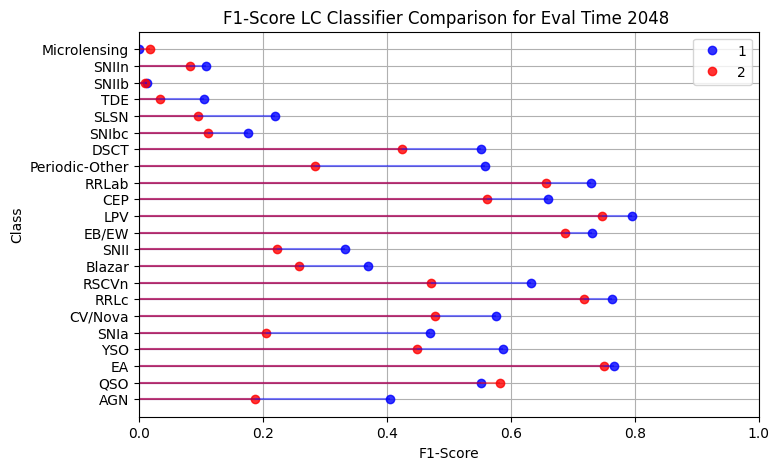

In [19]:
def compare_models(d1,d2, eval_time= 2048):

    f1_baseline = []
    f1_finetune = []

    fig,ax = plt.subplots(1,1,figsize = (8,5))
    for key,value in data_dict_1.items():
        if key in DICT.keys():
            #print(key,value)
            f1_baseline.append(value['f1-score'])
    df_1 = pd.DataFrame({'group':DICT.keys(), 'values':f1_baseline })
    ordered_df_1 = df_1#.sort_values(by='values')
    my_range_1=range(1,len(df_1.index)+1)
    

    for key,value in data_dict_2.items():
        if key in DICT.keys():
            #print(key,value)
            f1_finetune.append(value['f1-score'])
    df_2 = pd.DataFrame({'group':DICT.keys(), 'values':f1_finetune})
    ordered_df_2 = df_2#.sort_values(by='values')
    my_range_2=range(1,len(df_2.index)+1)
    plt.plot(ordered_df_1['values'].values, my_range_1, "o", alpha = 0.8,color='blue')
    plt.plot(ordered_df_2['values'].values, my_range_2, "o", alpha = 0.8,color='red')

    plt.legend(['1','2'])
    
    # The horizontal plot is made using the hline function
    plt.hlines(y=my_range_1, xmin=0, xmax=ordered_df_1['values'], color='blue', alpha = 0.5)
    
    # The horizontal plot is made using the hline function
    plt.hlines(y=my_range_2, xmin=0, xmax=ordered_df_2['values'], color='red', alpha = 0.5)

    # Add titles and axis names
    plt.yticks(my_range_1, ordered_df_1['group'])
    plt.title(f"F1-Score LC Classifier Comparison for Eval Time {eval_time} ", loc='center')

    plt.xlabel('F1-Score')
    plt.ylabel('Class')
    plt.xlim(0,1)
    #plt.xticks(np.arange(0,1,50), ordered_df_1['group'])
    plt.grid('on', )
    # Show the plot
    plt.show()
compare_models(data_dict_1,data_dict_2)

In [16]:
transient =  {
    "SNIa": 4,
    "SNII": 9,
    "SNIbc": 16,
    "SLSN": 17,
    "TDE": 18,
    "SNIIb": 19,
    "SNIIn": 20,
    "Microlensing": 21
}
stochastic =  {
    "AGN": 0,
    "QSO": 1,
    "YSO": 3,
    "CV/Nova": 5,
    "Blazar": 8,
}
periodic =  {
    "EA": 2,
    "RRLc": 6,
    "RSCVn": 7,
    "EB/EW": 10,
    "LPV": 11,
    "CEP": 12,
    "RRLab": 13,
    "Periodic-Other": 14,
    "DSCT": 15,
}

In [17]:

trans_f1 = []
stoch_f1 = []
per_f1 = []
for class_key, value in data_dict_1.items():
    #print(class_key)
    if class_key in DICT.keys():
        
        if class_key in transient.keys():
            trans_f1.append(value['f1-score'])
        if class_key in stochastic.keys():
            stoch_f1.append(value['f1-score'])
        if class_key in periodic.keys():
            per_f1.append(value['f1-score'])
print('group eval:')
print('trans',np.mean(trans_f1))
print('stoch',np.mean(stoch_f1))

print('per',np.mean(per_f1))


group eval:
trans 0.09137402124221418
stoch 0.3075233844676247
per 0.44516766236377314


In [18]:

trans_f1 = []
stoch_f1 = []
per_f1 = []
for class_key, value in data_dict_2.items():
    #print(class_key)
    if class_key in DICT.keys():
        
        if class_key in transient.keys():
            trans_f1.append(value['f1-score'])
        if class_key in stochastic.keys():
            stoch_f1.append(value['f1-score'])
        if class_key in periodic.keys():
            per_f1.append(value['f1-score'])
print('group eval:')    
print('trans',np.mean(trans_f1))
print('stoch',np.mean(stoch_f1))
print('per',np.mean(per_f1))

group eval:
trans 0.09057053026767672
stoch 0.3213394733576514
per 0.46253493405430646


In [19]:
adfadf

NameError: name 'adfadf' is not defined

In [21]:
def early_as(path_1:str, before_time:int,supress_cm = False,supress_dict = False):
    path_args = glob.glob(f"{path_1}*args*")[0]
    #print(path_args)
    with open(path_args, 'r') as file:
        args = yaml.safe_load(file)
    #print('Initializing models') 
    model = LightCurveClassifier(**args) 
    #print('Loading checkpoints')
    checkpoint_path_clip = glob.glob(
        f"{path_1}*my_best_checkpoint*"
    ) 
    #print(checkpoint_path_clip[-1])
    checkpoint_clip = torch.load(checkpoint_path_clip[-1], map_location=torch.device('cuda:2'))
    od_atat = OrderedDict() 
    for key in checkpoint_clip["state_dict"].keys(): 
            #print(key)
            if 'project' in key:
                continue
            if 'model' in key:
                od_atat[key.replace("model.", "")] = checkpoint_clip["state_dict"][key]

    model.load_state_dict(od_atat,strict=True)
    args['general']['data_root'] = 'data/datasets/ZTF_ff/final/LC_MD_FEAT_240627_windows_200_12'
    args['general']['use_sampler'] = False
    args['general']['batch_size'] = 256

    pl_datal = LitData(**args['general'])
    dataloader = pl_datal.test_dataloader() 
    target = None
    preds_out = None

    model.eval().to(device = 'cuda:2')  

    for b1 in tqdm(dataloader):

        #print(b1.keys())
        b1 = {key:value.to(device = 'cuda:2') for key, value in b1.items()}
        #print(b1['time'].shape,b1['mask'].shape)
        #b1['data'][:,before_time:,:] = 0
        #b1['time'][:,before_time:,:] = 0
        #b1['mask'] = (b1['data'] !=0)
        mask = torch.ones_like(b1['mask'])
        #mask[before_time:,:] = 0 
        #b1['mask'] = b1['mask'] * mask
        lc_emb = model(**b1)  
        t = b1['labels']
        preds_out = (
            np.concatenate([preds_out, torch.argmax(lc_emb, axis=1).detach().cpu().numpy()])
            if preds_out is not None
            else torch.argmax(lc_emb, axis=1).cpu().detach().numpy()
        )
        target = (
            np.concatenate([target, t.cpu().detach().numpy()])
            if target is not None
            else t.detach().cpu().numpy()
        )
    results = preds_out
    classification = classification_report(target, results, target_names=list(DICT.keys()),digits = 4)
    data_dict =  classification_report(target, results, target_names=list(DICT.keys()),digits = 4, output_dict=True)    
    if supress_dict == 0:
        print(classification)
    if supress_cm == 0:        
        from src.utils.plottinglib import elasticc_confusion_matrix
        out_metrics_balto = classification_report(
            target, results, target_names=list(DICT.keys()), output_dict=True
        )["macro avg"]
        template_balto = ""
        for key in out_metrics_balto.keys():
            template_balto += " {} : {:.3f} ".format(key.upper(), out_metrics_balto[key])
        fig, axes = plt.subplots(1, 1, figsize=(12, 12))
        elasticc_confusion_matrix(
            y_true=np.array(target).astype(int),
            y_pred=np.array(results).astype(int),
            classes= np.array(list(DICT.keys())),
            ax=axes,
            normalize=True,
            
            title=f" FClassifier Results [TEST] \n\n {template_balto}",
        )
        plt.show()
    
    return data_dict

In [22]:
data_dict_1['macro avg']['f1-score']

0.285232638797718

In [23]:
e_times = [10,20,30,40,50,60,70,80,90,100,110,120,130,140,150,160,170,180,200]
macro_f1_eval_times = {'d1':[],'d2':[]}
for eval_time in e_times:
    data_dict_1 = early_as(path_1, before_time = eval_time,supress_cm=True,supress_dict=True)
    data_dict_2 = early_as(path_2, before_time = eval_time,supress_cm=True,supress_dict=True)
    macro_f1_eval_times['d1'].append(data_dict_1['macro avg']['f1-score'])
    macro_f1_eval_times['d2'].append(data_dict_2['macro avg']['f1-score'])
    compare_models(data_dict_1,data_dict_2,eval_time)

data_dict_1 = produce_report(path_1)
data_dict_2 = produce_report(path_2) 

using set test total of idx : 50501 
                 use_lightcurves True, use_metadata False 
                 use_features False 
                      use MTA False
using set_Type test
NOT USING SAMPLER FOR DATASET test


 20%|█▉        | 39/197 [00:03<00:15, 10.22it/s]


KeyboardInterrupt: 

In [15]:
import seaborn as sns

sns.lineplot(macro_f1_eval_times[::-1])
#plt.legend(['baseline','pretrained'])

plt.title('F1-score for ')
plt.xticks(list(range(len(e_times))),[str(time) for time in e_times])
plt.xlabel('Max Evaluated Time')
plt.ylabel('F1-score')
plt.grid('on')

KeyError: slice(None, None, -1)

modl is not sample dependent